In [34]:
import spectral
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [35]:
def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    normalized = (image - min_val) / (max_val - min_val)
    return normalized

In [36]:
def find_nearest_band(wavelengths, target_wavelength):
    wavelengths_float = np.array([float(w) for w in wavelengths])
    return np.argmin(np.abs(wavelengths_float - target_wavelength))


In [37]:
def get_hyp_rgb(image, wavelengths, save_path):
    try:
        image = image.load()
    except AttributeError:
        if not isinstance(image, np.ndarray):
            raise ValueError("Input image is neither a recognized format with a load() method nor a numpy array.")
    red_band_index = find_nearest_band(wavelengths, 660)
    green_band_index = find_nearest_band(wavelengths, 550)
    blue_band_index = find_nearest_band(wavelengths, 450)
    # print(wavelengths[:20])   # first 20 wavelength values

    # Extract the RGB bands
    red_band = image[:, :, [red_band_index]]
    green_band = image[:, :, [green_band_index]]
    blue_band = image[:, :, [blue_band_index]]

    # Normalize the bands to the range [0, 1]
    red_normalized = normalize_image(red_band)
    green_normalized = normalize_image(green_band)
    blue_normalized = normalize_image(blue_band)
    
    

    # Stack the normalized bands to create an RGB image
    rgb_image = np.stack((red_normalized, green_normalized, blue_normalized), axis=-1)
    
    # Squeeze any extra dimensions
    rgb_image_squeezed = np.squeeze(rgb_image)
    

    # Convert the RGB image to the range [0, 255] and save it as a PNG file
    rgb_image_uint8 = (rgb_image_squeezed * 255).astype(np.uint8)

    rgb_image_uint8 = cv2.cvtColor(rgb_image_uint8, cv2.COLOR_RGB2BGR)
    try:
        output_path =save_path[:-4]+".png"
        cv2.imwrite(output_path, rgb_image_uint8)
        print(f"Image saved as {output_path}")
    except Exception as e:
        print("Error saving the image:", e)

#     # Display the RGB image
#     import matplotlib.pyplot as plt

    plt.imshow(rgb_image_squeezed)
    plt.show()
    return rgb_image_squeezed

/tmp/ipykernel_27678/160095164.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized = (image - min_val) / (max_val - min_val)


Image saved as /home/sriram/ANU/data/aruco_only_arucoplants/calibrated/corrected/003-specim-fx17_calibrated_corrected-FX17.png


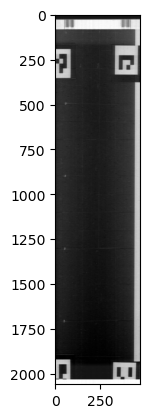

In [46]:
header_file = r'/home/sriram/ANU/data/aruco_only_arucoplants/calibrated/corrected/003-specim-fx17_calibrated_corrected-FX17.hdr'
image = spectral.open_image(header_file)
wavelengths = image.metadata['wavelength']
get_hyp_rgb(image, wavelengths, header_file)
wavelengths = np.array(wavelengths, dtype=float)
# for i in range(wavelengths.shape[0]):
#     img = image[:, :, i]
#     plt.imshow(img, cmap='gray')
#     plt.title(f'Band {i} - Wavelength: {wavelengths[i]} nm')
#     plt.colorbar(label='Reflectance / Intensity')
#     plt.axis('off')
#     plt.show()




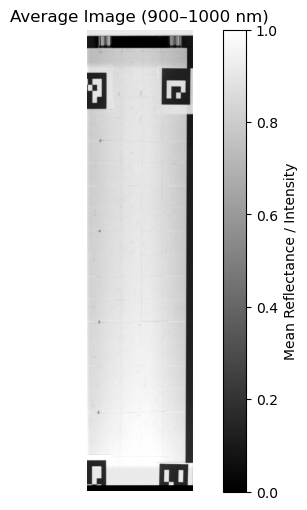

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import spectral

# Path to ENVI header file
# hdr_path = r'/home/sriram/ANU/data/aruco_only_arucoplants/calibrated/corrected/003-specim-fx17_calibrated_corrected-FX17.hdr'
hdr_path = r'/home/sriram/ANU/data/aruco_only_arucoplants/calibrated/003-specim-fx17_calibrated.hdr'

# Open hyperspectral image
img = spectral.open_image(hdr_path)

# Load hyperspectral cube
data = img.load()   # shape: (H, W, Bands)

# Read wavelengths from metadata
wls = img.metadata.get("wavelength")

if wls is None:
    raise ValueError("No wavelength information found in metadata.")

# Convert wavelength strings to float array
wls = np.array([float(w) for w in wls])

# Find band indices between 900 and 1000 nm
band_mask = (wls >= 900) & (wls <= 1000)

if not np.any(band_mask):
    raise ValueError("No bands found between 900 and 1000 nm.")

# Average selected bands
avg_img = np.mean(data[:, :, band_mask], axis=2)

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(avg_img, cmap="gray")
plt.title("Average Image (900–1000 nm)")
plt.colorbar(label="Mean Reflectance / Intensity")
plt.axis("off")
plt.show()

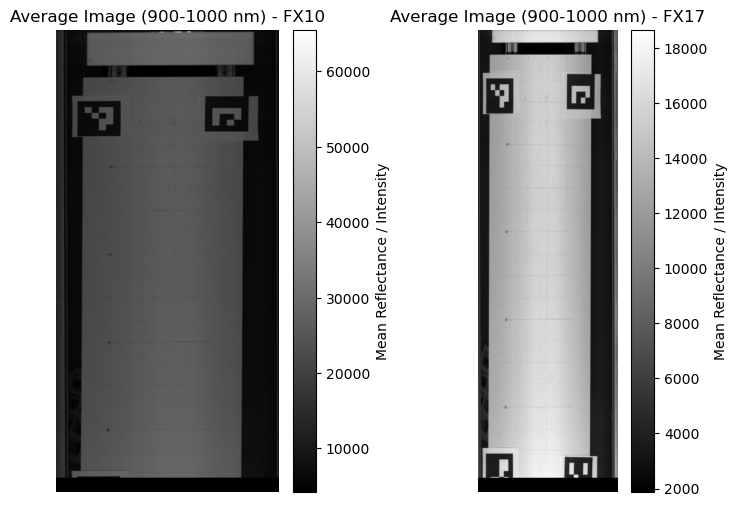

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import spectral

# Path to ENVI header file
# fx17path = r'/home/sriram/ANU/data/aruco_only_arucoplants/calibrated/corrected/004-specim-fx17_calibrated_corrected-FX17.hdr'
# fx10path = r'/home/sriram/ANU/data/aruco_only_arucoplants/calibrated/004-specim-fx10_calibrated.hdr'

fx17path = r'/home/sriram/ANU/data/aruco_only_arucoplants/003-specim-fx17.hdr'
fx10path = r'/home/sriram/ANU/data/aruco_only_arucoplants/003-specim-fx10.hdr'

# fx17path = r'/home/sriram/ANU/data/csiro_fx10_17_2_wheat/calibrated/corrected/003-specim-fx17_calibrated_corrected-FX17.hdr'
# fx10path = r'/home/sriram/ANU/data/csiro_fx10_17_2_wheat/calibrated/003-specim-fx10_calibrated.hdr'


def plotimg(hdr_path):
    # Open hyperspectral image
    img = spectral.open_image(hdr_path)

    # Load hyperspectral cube
    data = img.load()   # shape: (H, W, Bands)

    # Read wavelengths from metadata
    wls = img.metadata.get("wavelength")

    if wls is None:
        raise ValueError("No wavelength information found in metadata.")

    # Convert wavelength strings to float array
    wls = np.array([float(w) for w in wls])

    # Find band indices between 900 and 1000 nm
    band_mask = (wls >= 900) & (wls <= 1000)

    if not np.any(band_mask):
        raise ValueError("No bands found between 900 and 1000 nm.")

    # Average selected bands
    avg_img = np.mean(data[:, :, band_mask], axis=2)
    return avg_img

avg_img1 = plotimg(fx10path)
avg_img2 = plotimg(fx17path)

# Plot
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(avg_img1, cmap="gray")
plt.title("Average Image (900-1000 nm) - FX10")
plt.colorbar(label="Mean Reflectance / Intensity")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(avg_img2, cmap="gray")
plt.title("Average Image (900-1000 nm) - FX17")
plt.colorbar(label="Mean Reflectance / Intensity")
plt.axis("off")
plt.show()